# Benchmark results and figures

This notebook loads saved rare-cell downsampling benchmark results and generates publication-style figures for rare-cell recovery, neighborhood preservation, and representation comparison.

**Required input:** `results/tables/{output_prefix}__benchmark_results.csv`

**Outputs saved to:** `results/figures/` (PNG and PDF), `results/tables/{output_prefix}__figure_index.csv`


## Setup

Run this notebook after `rare_cell_downsampling_benchmark.ipynb` has saved result tables.


In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
for _p in [PROJECT_ROOT, PROJECT_ROOT / "src"]:
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

from rarecell.benchmark import TABLES_DIR
from rarecell.benchmark_plots import save_all_standard_plots
from rarecell.figure_utils import set_plot_style
from rarecell.naming import resolve_existing_output_prefix

set_plot_style()

requested_output_prefix = "pbmc5k_b_cell"
output_prefix = requested_output_prefix
results_path = TABLES_DIR / f"{output_prefix}__benchmark_results.csv"
summary_path = TABLES_DIR / f"{output_prefix}__metric_summary.csv"


## Load benchmark results

The primary result table is produced by `rare_cell_downsampling_benchmark.ipynb`.

In [2]:
if not results_path.exists():
    output_prefix = resolve_existing_output_prefix(TABLES_DIR, requested_output_prefix)
    results_path = TABLES_DIR / f"{output_prefix}__benchmark_results.csv"
    summary_path = TABLES_DIR / f"{output_prefix}__metric_summary.csv"
print(f"Using output prefix: {output_prefix!r}")
results = pd.read_csv(results_path)
display(results.head())

summary = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()
if not summary.empty:
    display(summary.head())


Using output prefix: 'pbmc5k_14'


,dataset,target_cell_type,target_label,label_key,fraction,retain_fraction,seed,representation,n_neighbors,n_cells_total,...,n_target_remaining,n_target,n_other,target_fraction,precision,recall,f1,neighborhood_purity,silhouette_target,target_silhouette
0,unknown,14,14,leiden,1.0,1.0,0,rna_pca,15,5527,...,32,32,5495,0.00579,1.0,0.96875,0.984127,0.958333,0.499258,0.499258
1,unknown,14,14,leiden,1.0,1.0,0,protein_pca,15,5527,...,32,32,5495,0.00579,0.8,0.37500,0.510638,0.277083,-0.003456,-0.003456
2,unknown,14,14,leiden,1.0,1.0,0,joint_pca,15,5527,...,32,32,5495,0.00579,1.0,0.96875,0.984127,0.950000,0.317227,0.317227
3,unknown,14,14,leiden,1.0,1.0,1,rna_pca,15,5527,...,32,32,5495,0.00579,1.0,0.96875,0.984127,0.958333,0.499258,0.499258
4,unknown,14,14,leiden,1.0,1.0,1,protein_pca,15,5527,...,32,32,5495,0.00579,0.8,0.37500,0.510638,0.277083,-0.003456,-0.003456


,representation,retain_fraction,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,neighborhood_purity_mean,neighborhood_purity_std,target_silhouette_mean,target_silhouette_std,n_target_mean,n_target_std
0,joint_pca,0.05,0.0,0.0,0.00000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,1.0,0.0
1,joint_pca,0.10,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.111111,0.022222,0.206280,0.089841,3.0,0.0
2,joint_pca,0.25,1.0,0.0,0.87500,0.088388,0.931429,0.050575,0.418333,0.028504,0.446047,0.043344,8.0,0.0
3,joint_pca,0.50,1.0,0.0,0.95000,0.027951,0.974194,0.014426,0.915000,0.030704,0.431311,0.004844,16.0,0.0
4,joint_pca,1.00,1.0,0.0,0.96875,0.000000,0.984127,0.000000,0.950000,0.000000,0.317227,0.000000,32.0,0.0


## Validate the result table

Checks that the required metric columns are present before generating figures.


In [3]:
required_columns = [
    "target_label", "retain_fraction", "seed", "representation",
    "n_target", "precision", "recall", "f1",
    "neighborhood_purity", "target_silhouette",
]
missing = [c for c in required_columns if c not in results.columns]
if missing:
    raise ValueError(f"Benchmark results are missing required columns: {missing}")
if results.empty:
    raise ValueError("Benchmark results table is empty.")
print(f"Loaded {len(results)} rows, {results['representation'].nunique()} representations, "
      f"{results['retain_fraction'].nunique()} fractions")


Loaded 75 rows, 3 representations, 5 fractions


## Generate benchmark figures

All standard figures are generated by `save_all_standard_plots()` from `src/rarecell/benchmark_plots.py`. Each figure is saved as both PNG and PDF. Paths are recorded in the figure index CSV.


In [4]:
plot_paths = save_all_standard_plots(results, output_prefix)
print(f"Saved {len(plot_paths)} figure files (PNG + PDF).")
for path in sorted(set(plot_paths)):
    print(f"  {path}")


Saved 20 figure files (PNG + PDF).
  /Users/zeyuyao/Documents/GitHub/rarecell-citeseq/results/figures/pbmc5k_14__neighborhood_purity_curve.pdf
  /Users/zeyuyao/Documents/GitHub/rarecell-citeseq/results/figures/pbmc5k_14__neighborhood_purity_curve.png
  /Users/zeyuyao/Documents/GitHub/rarecell-citeseq/results/figures/pbmc5k_14__neighborhood_purity_heatmap.pdf
  /Users/zeyuyao/Documents/GitHub/rarecell-citeseq/results/figures/pbmc5k_14__neighborhood_purity_heatmap.png
  /Users/zeyuyao/Documents/GitHub/rarecell-citeseq/results/figures/pbmc5k_14__rare_cell_f1_curve.pdf
  /Users/zeyuyao/Documents/GitHub/rarecell-citeseq/results/figures/pbmc5k_14__rare_cell_f1_curve.png
  /Users/zeyuyao/Documents/GitHub/rarecell-citeseq/results/figures/pbmc5k_14__rare_cell_f1_heatmap.pdf
  /Users/zeyuyao/Documents/GitHub/rarecell-citeseq/results/figures/pbmc5k_14__rare_cell_f1_heatmap.png
  /Users/zeyuyao/Documents/GitHub/rarecell-citeseq/results/figures/pbmc5k_14__rare_cell_precision_curve.pdf
  /Users/zeyu

## Display figures


pbmc5k_14__rare_cell_f1_curve.png


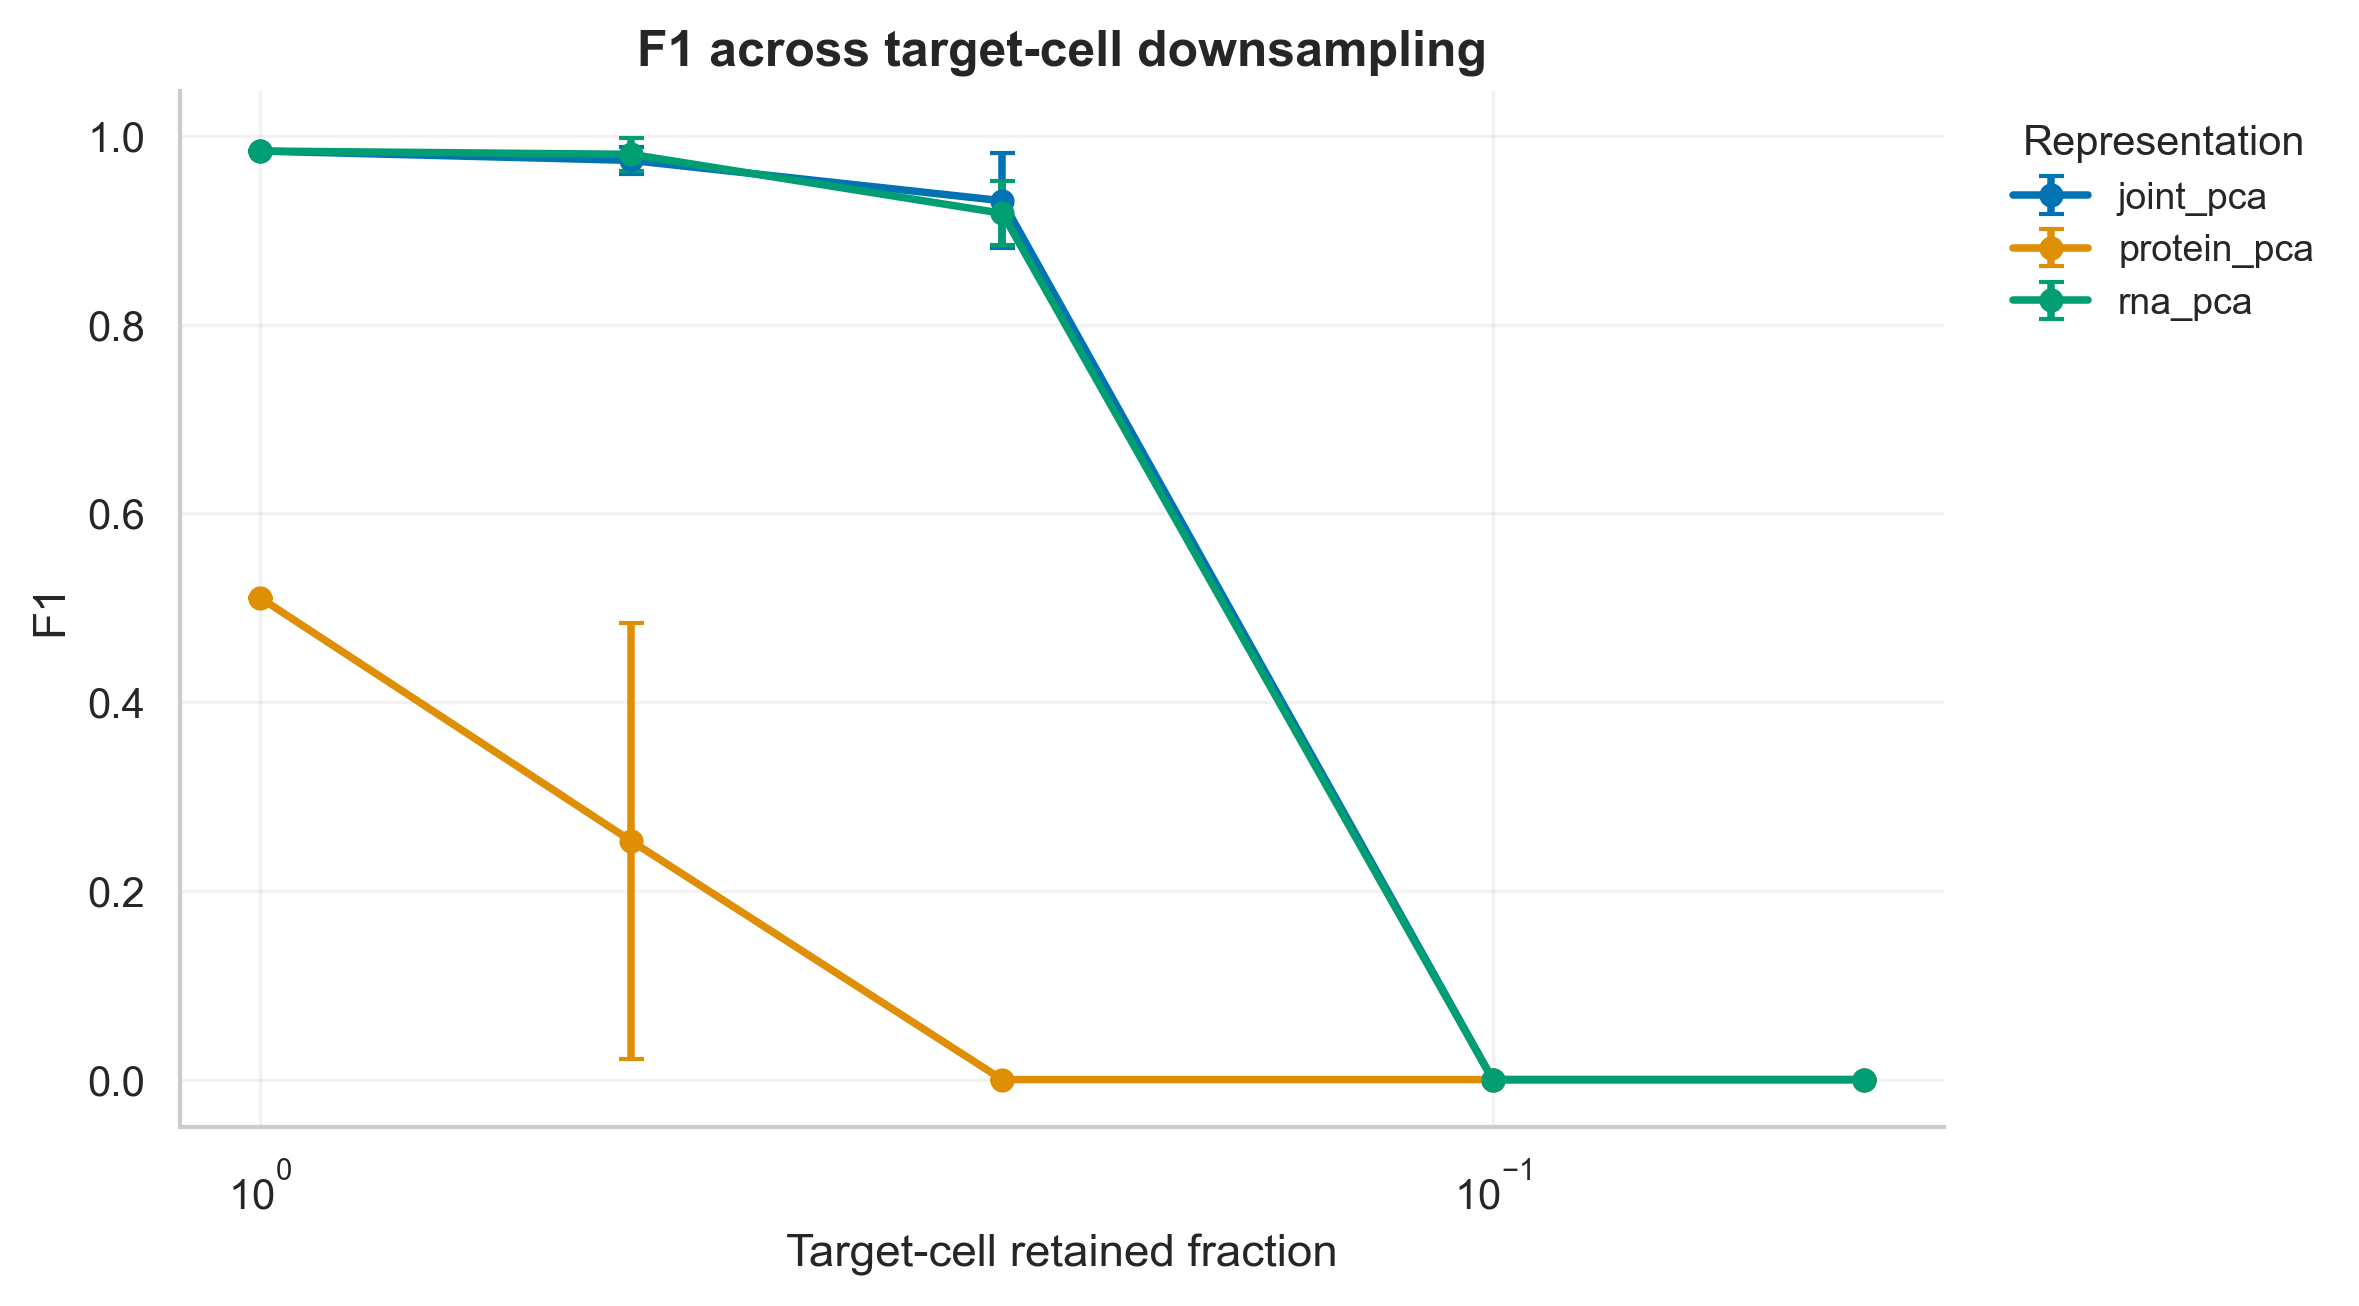

pbmc5k_14__rare_cell_recall_curve.png


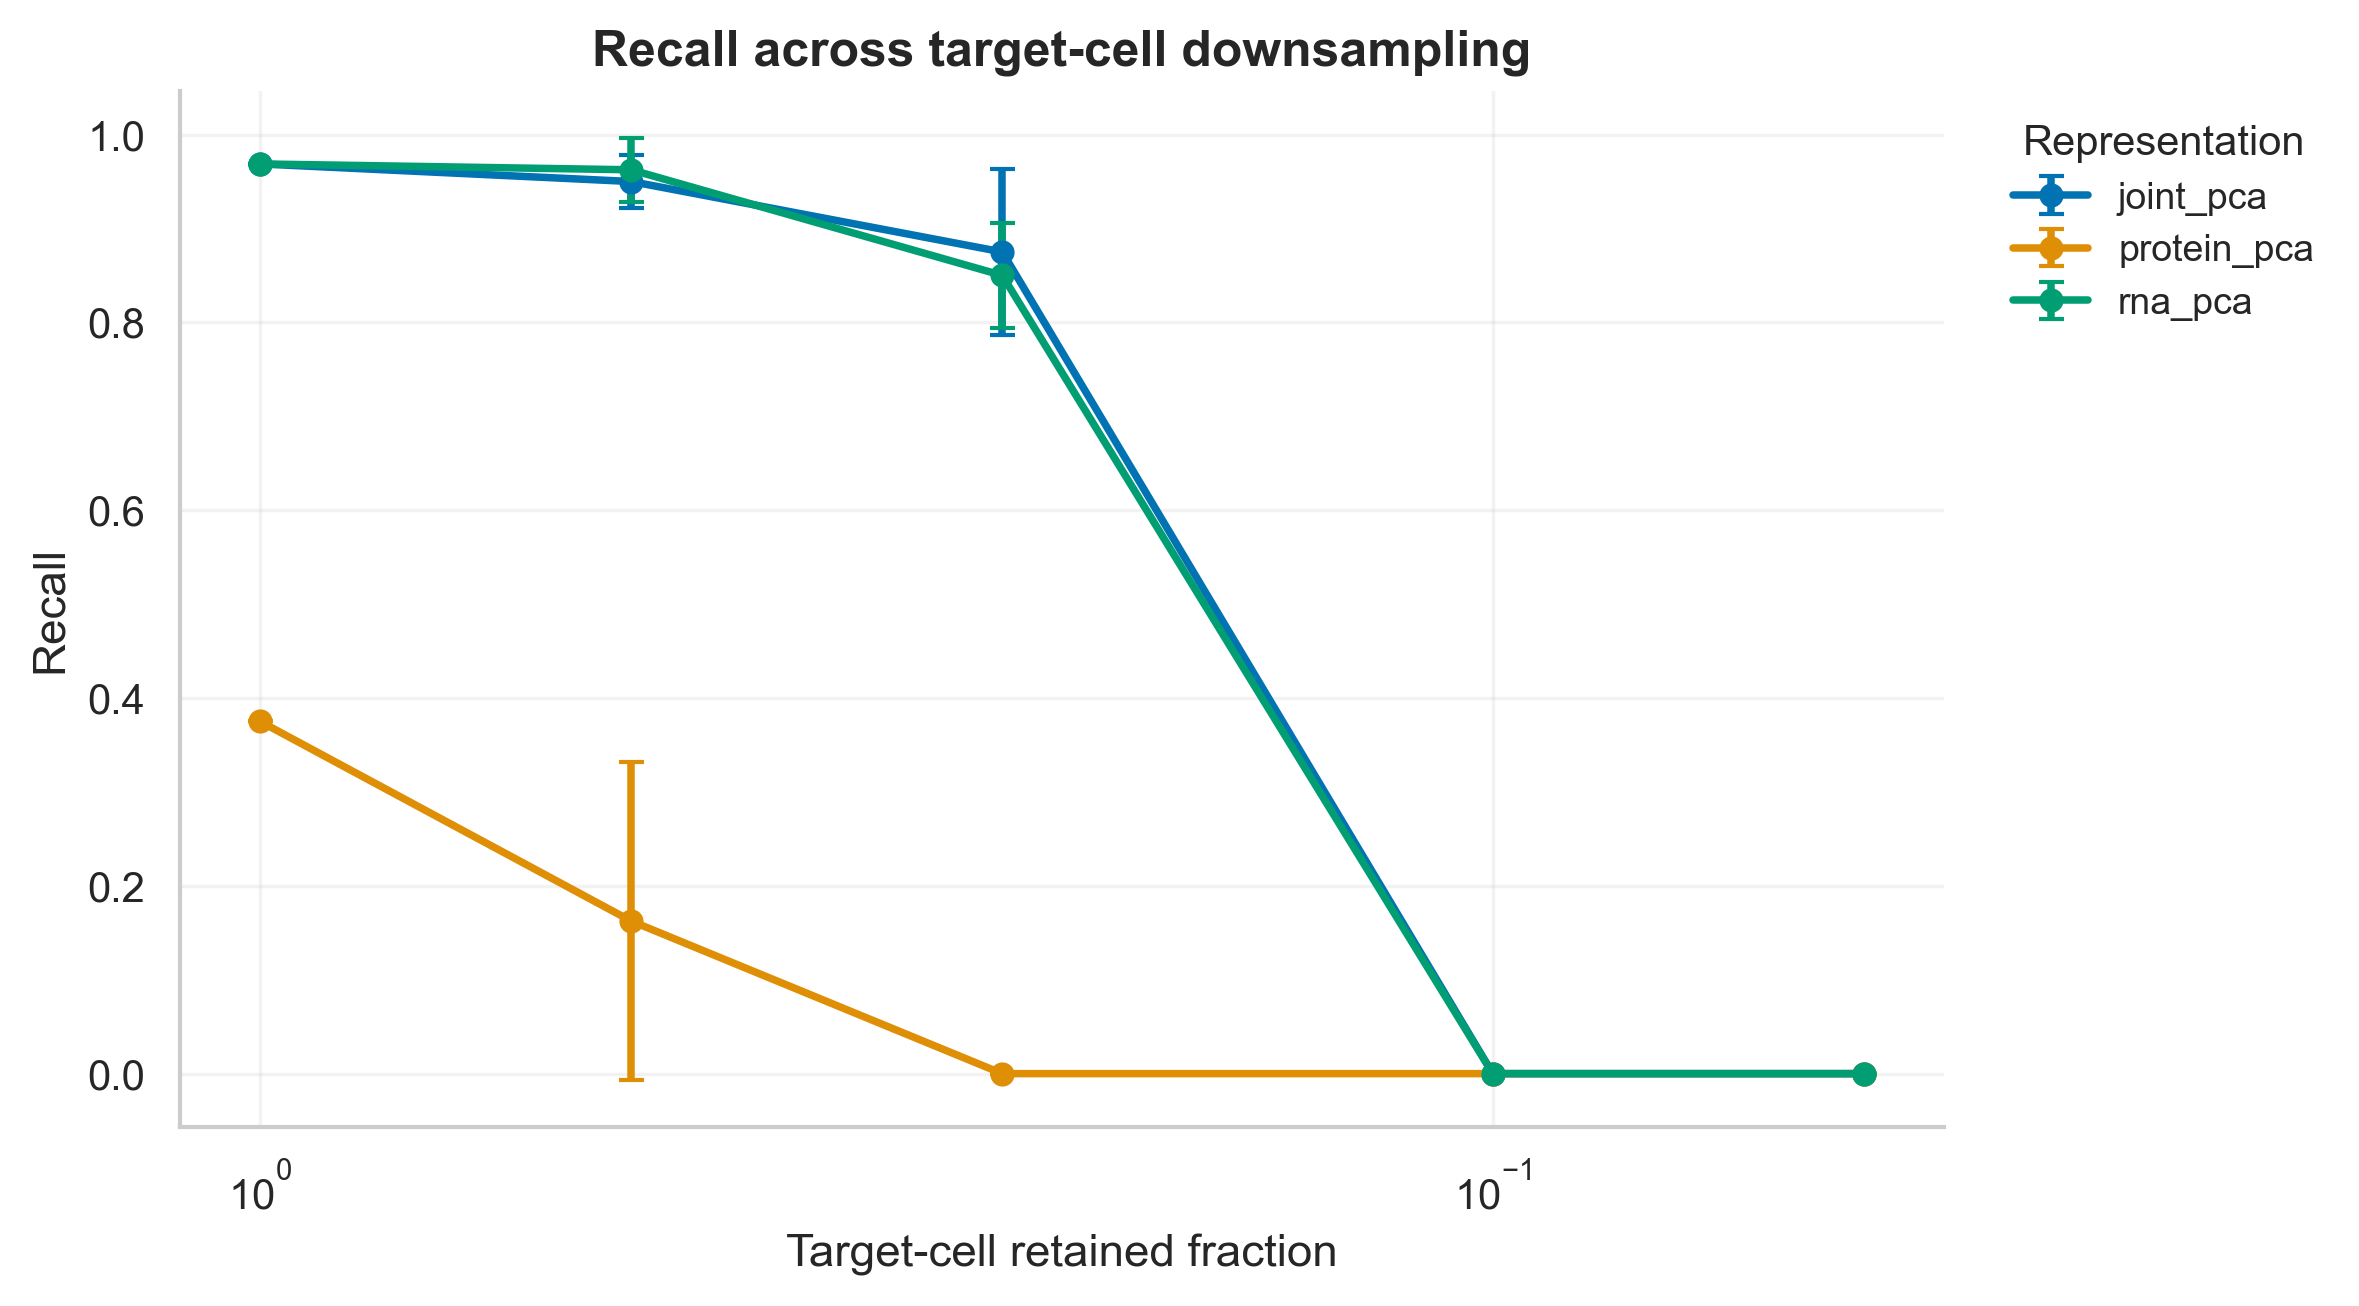

pbmc5k_14__rare_cell_precision_curve.png


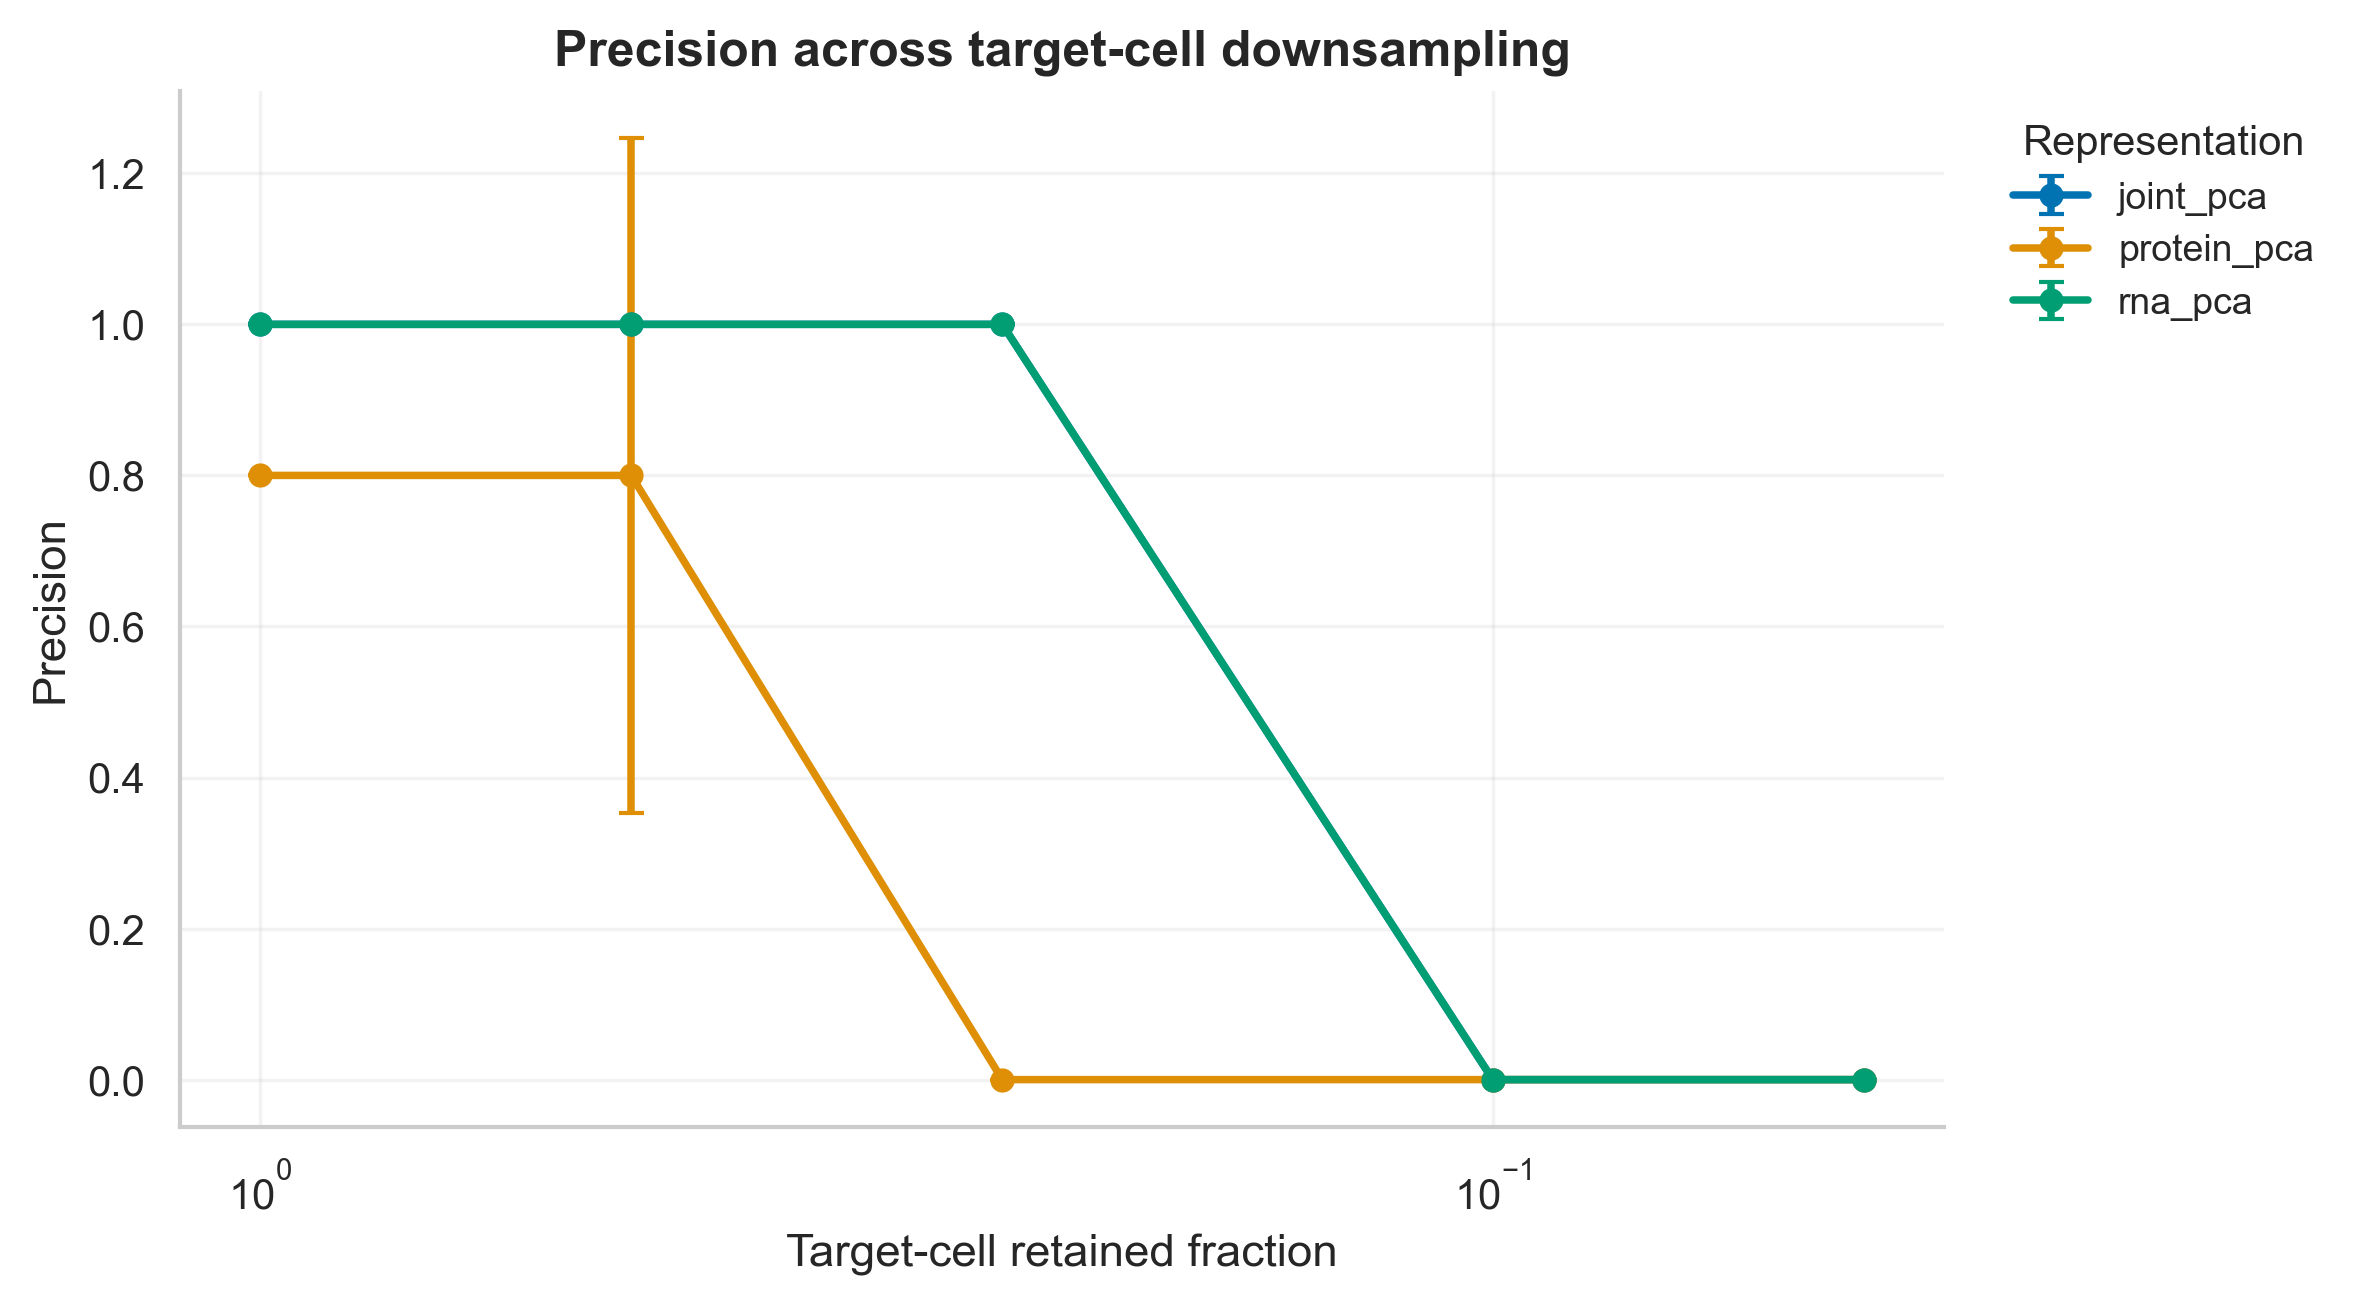

pbmc5k_14__neighborhood_purity_curve.png


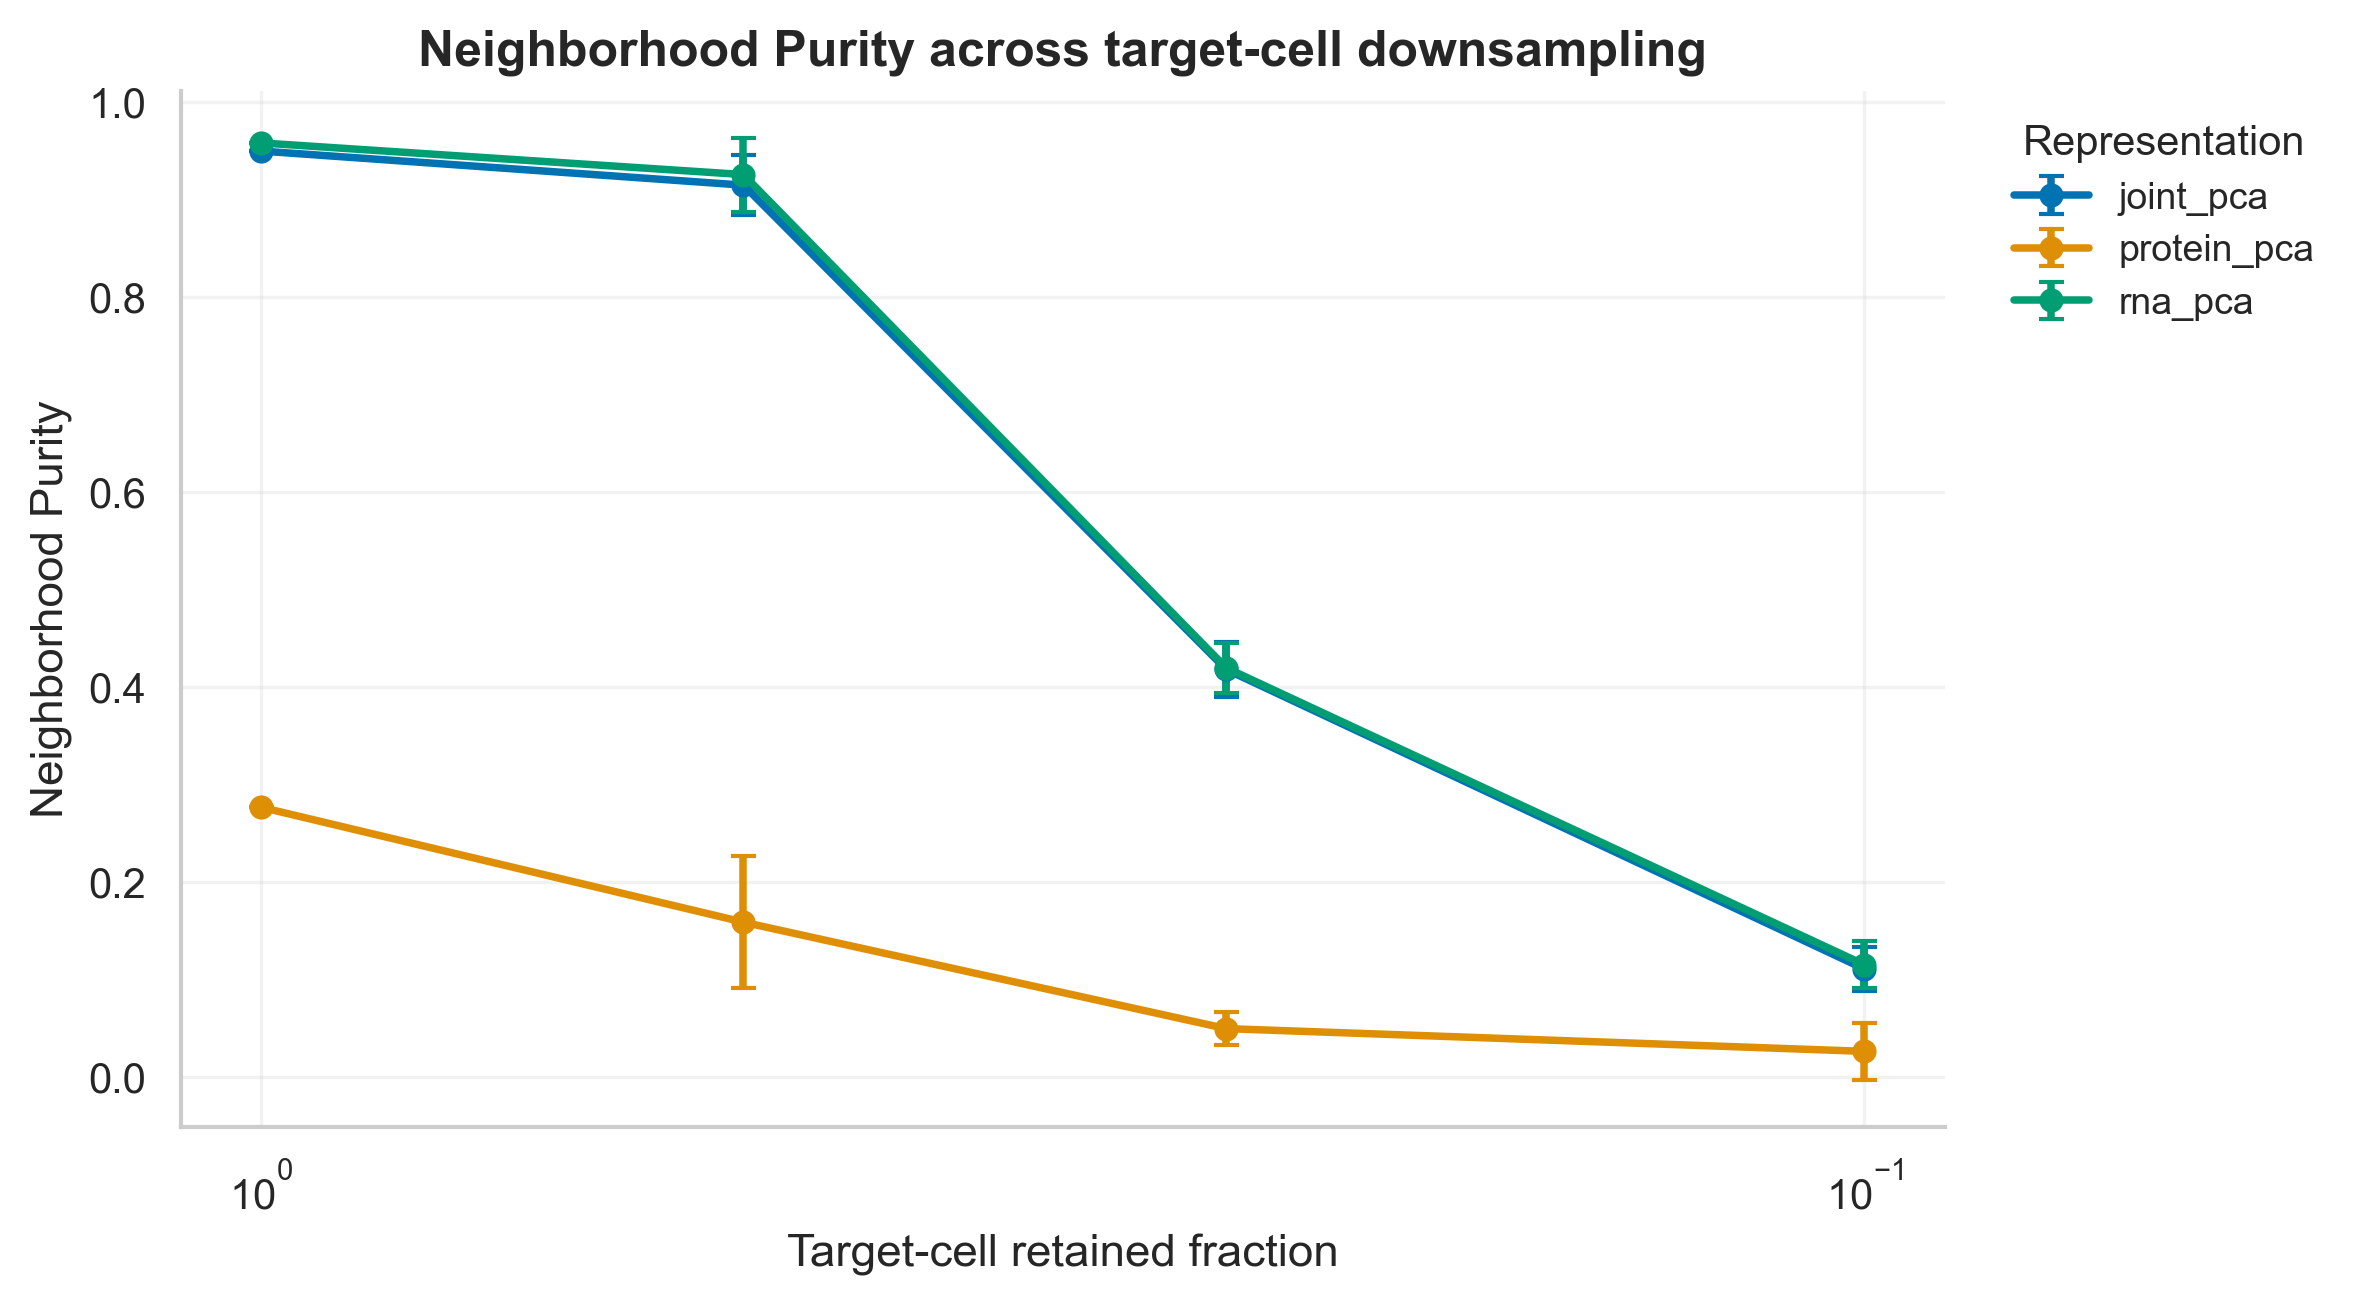

pbmc5k_14__target_silhouette_curve.png


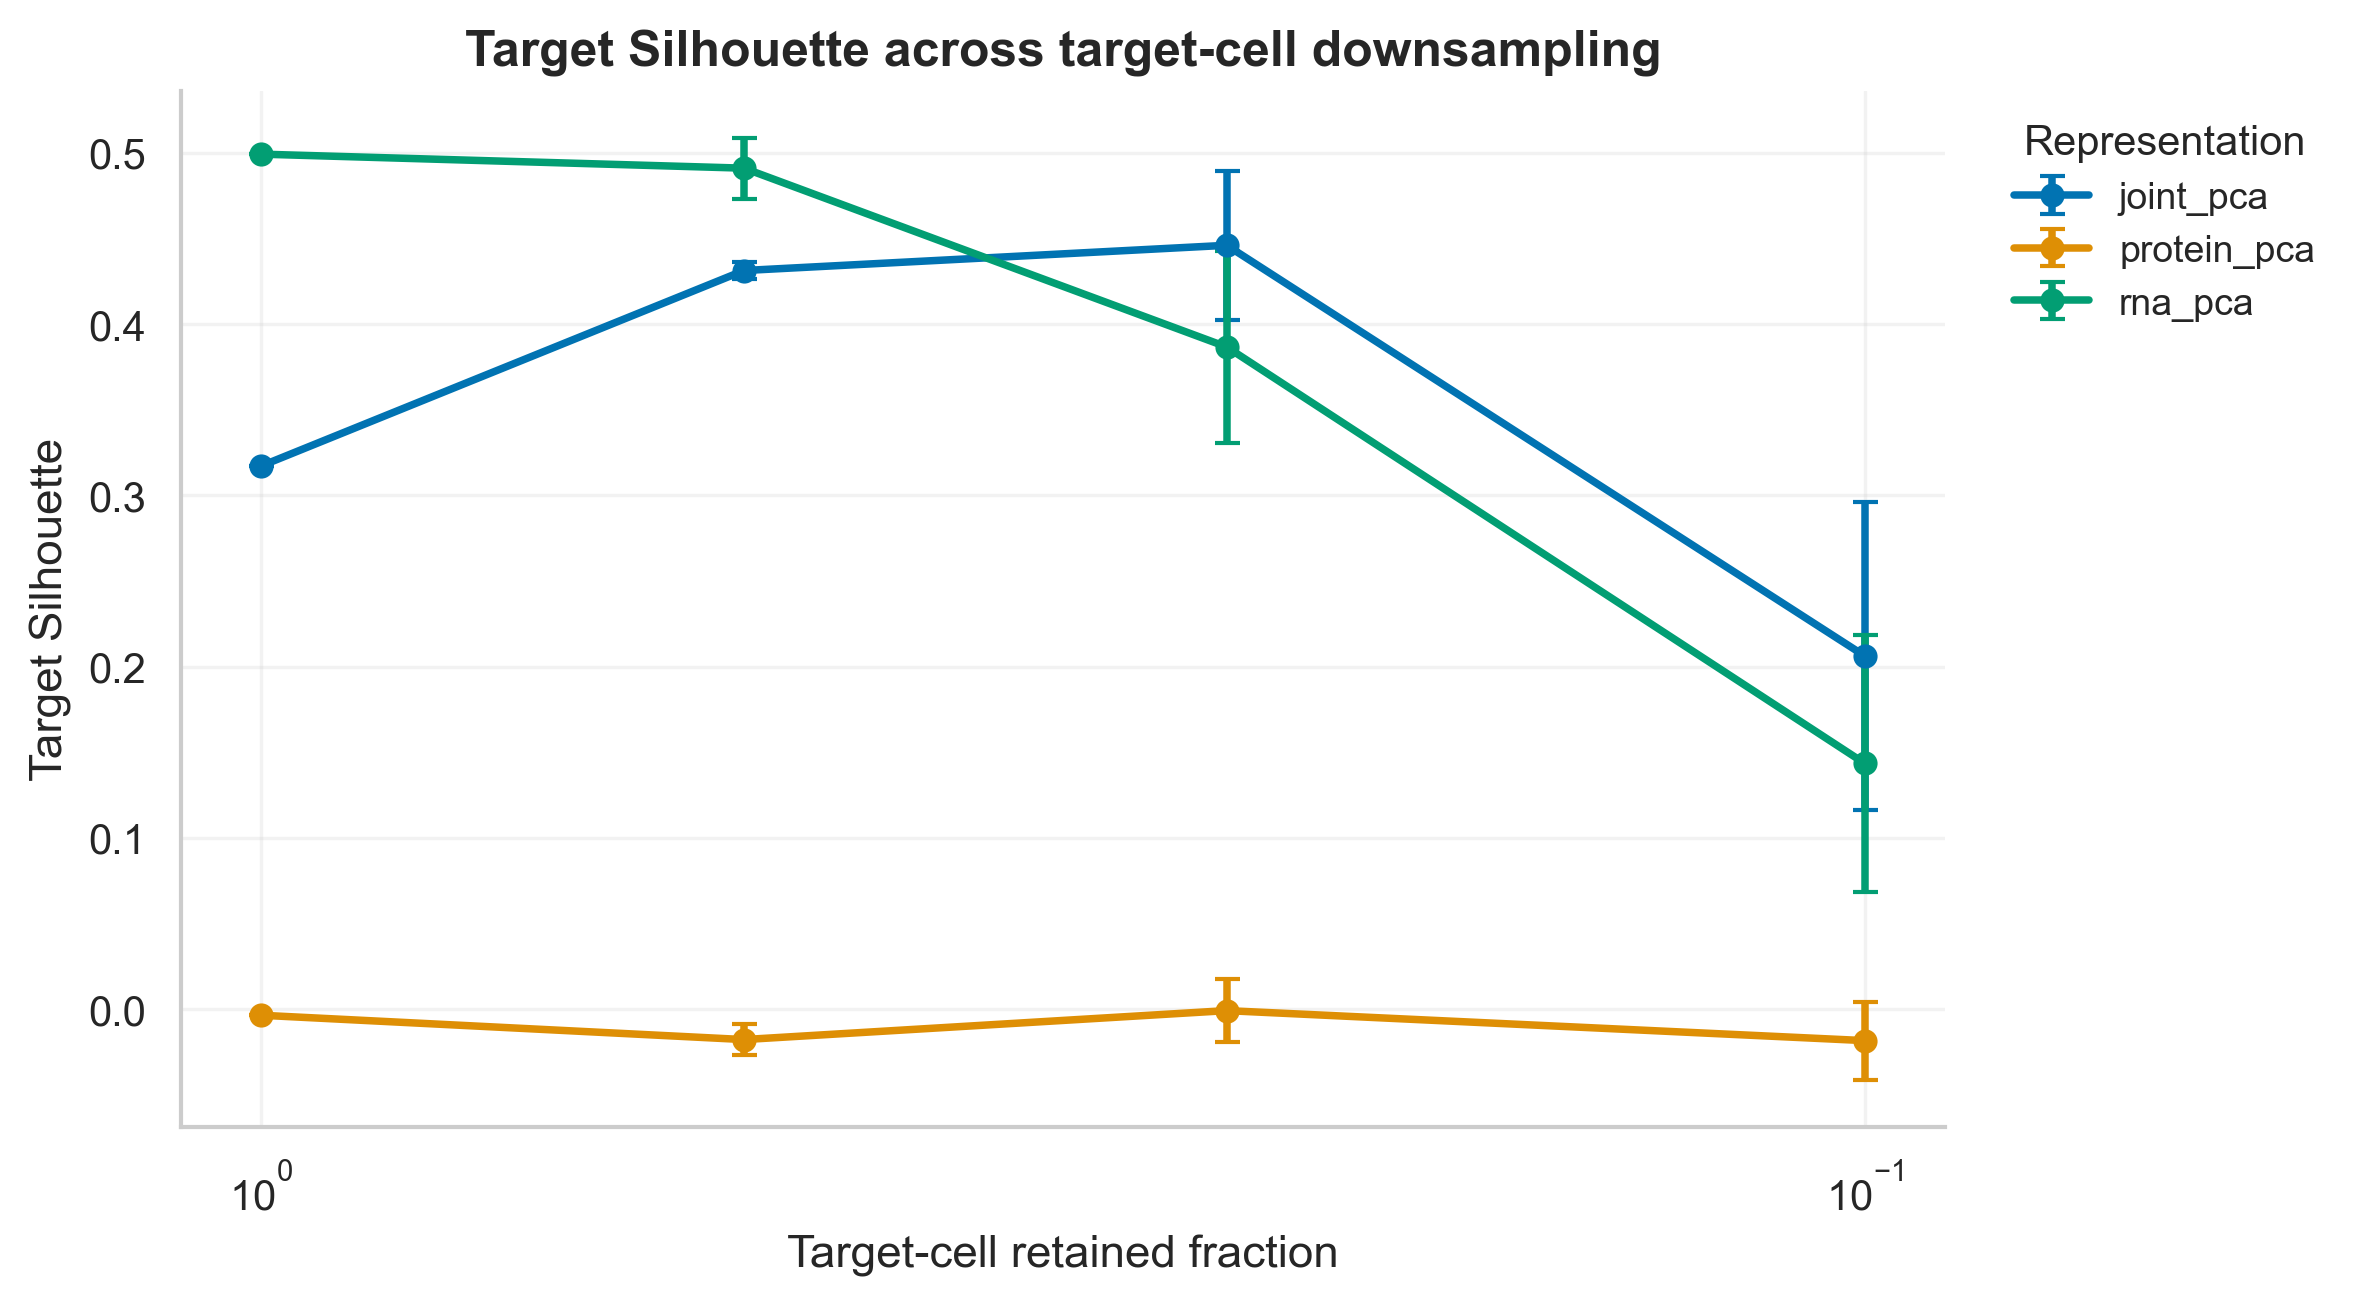

pbmc5k_14__target_cell_counts.png


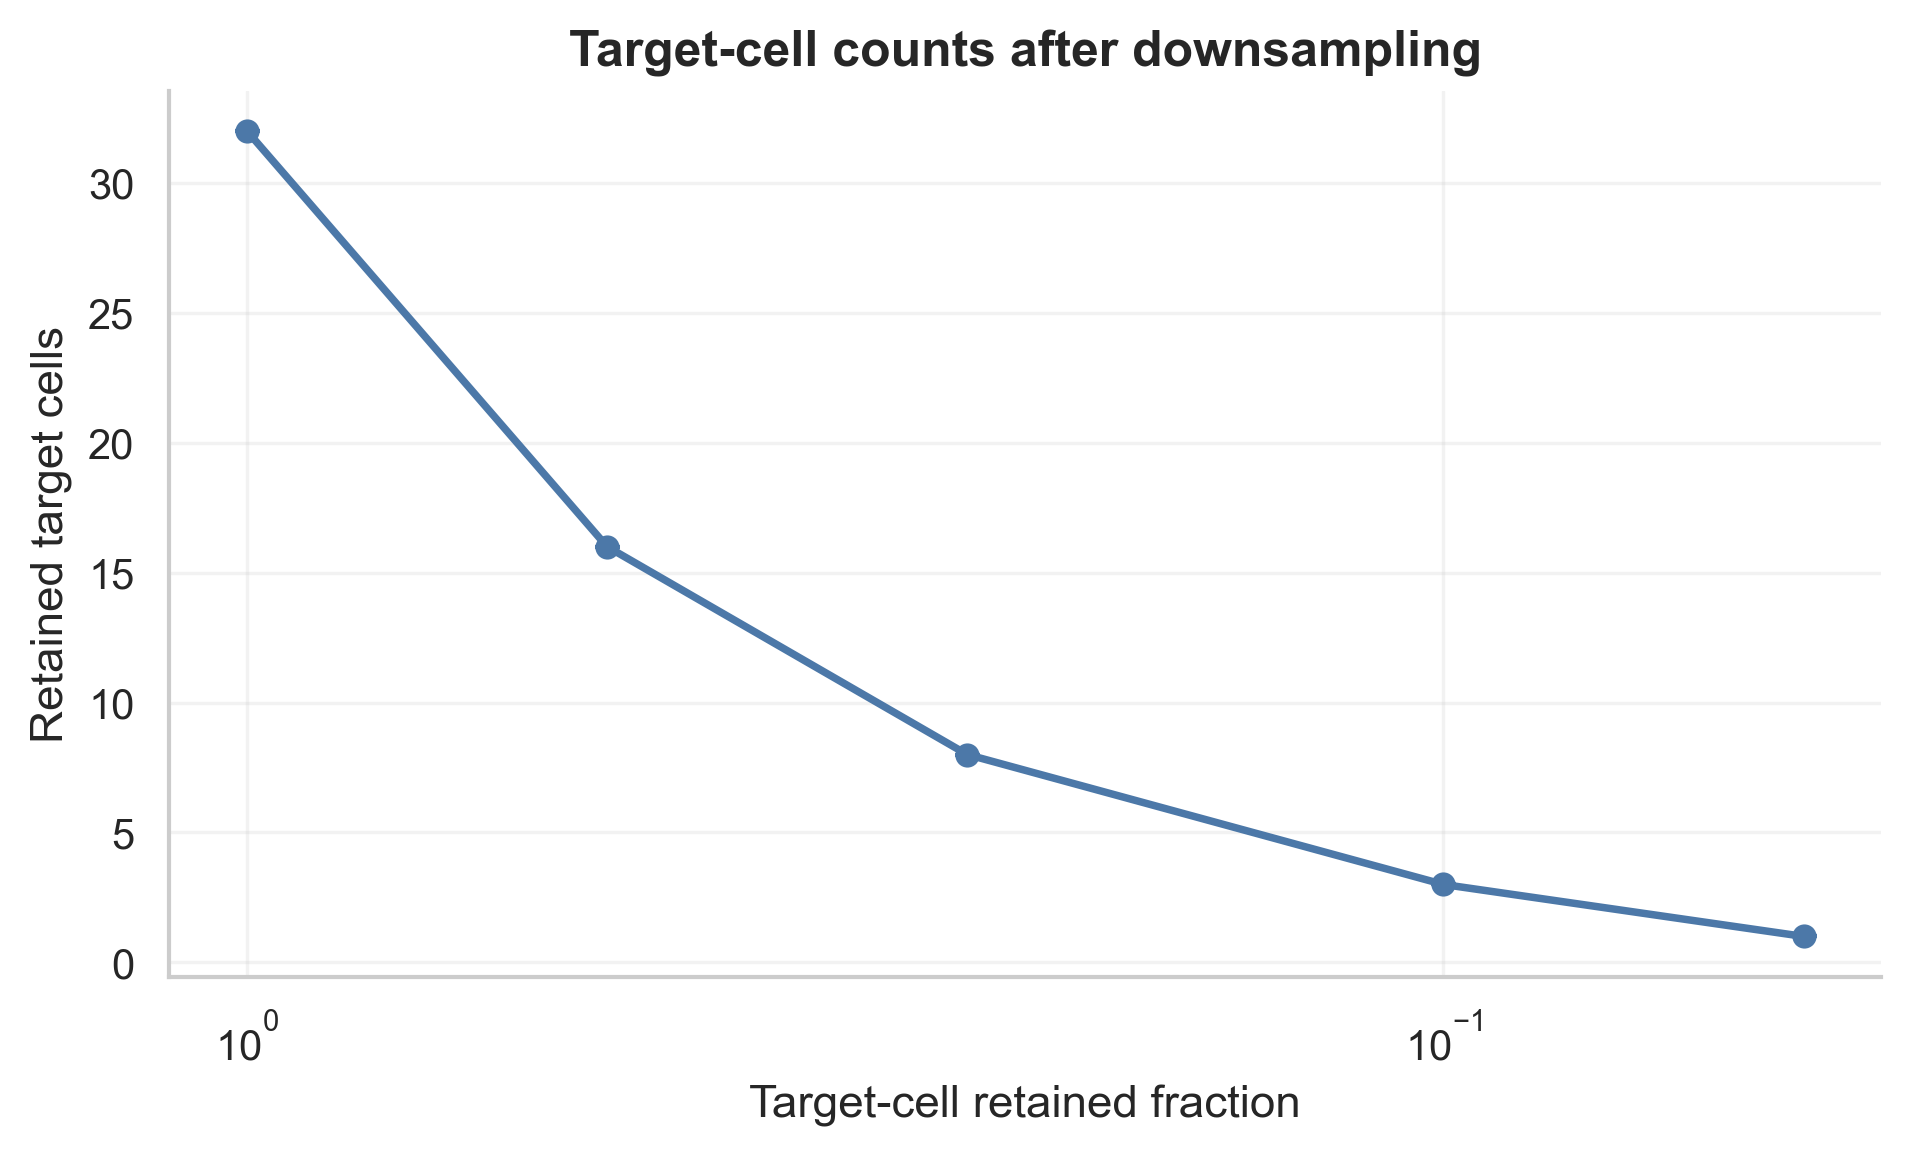

pbmc5k_14__rare_cell_f1_heatmap.png


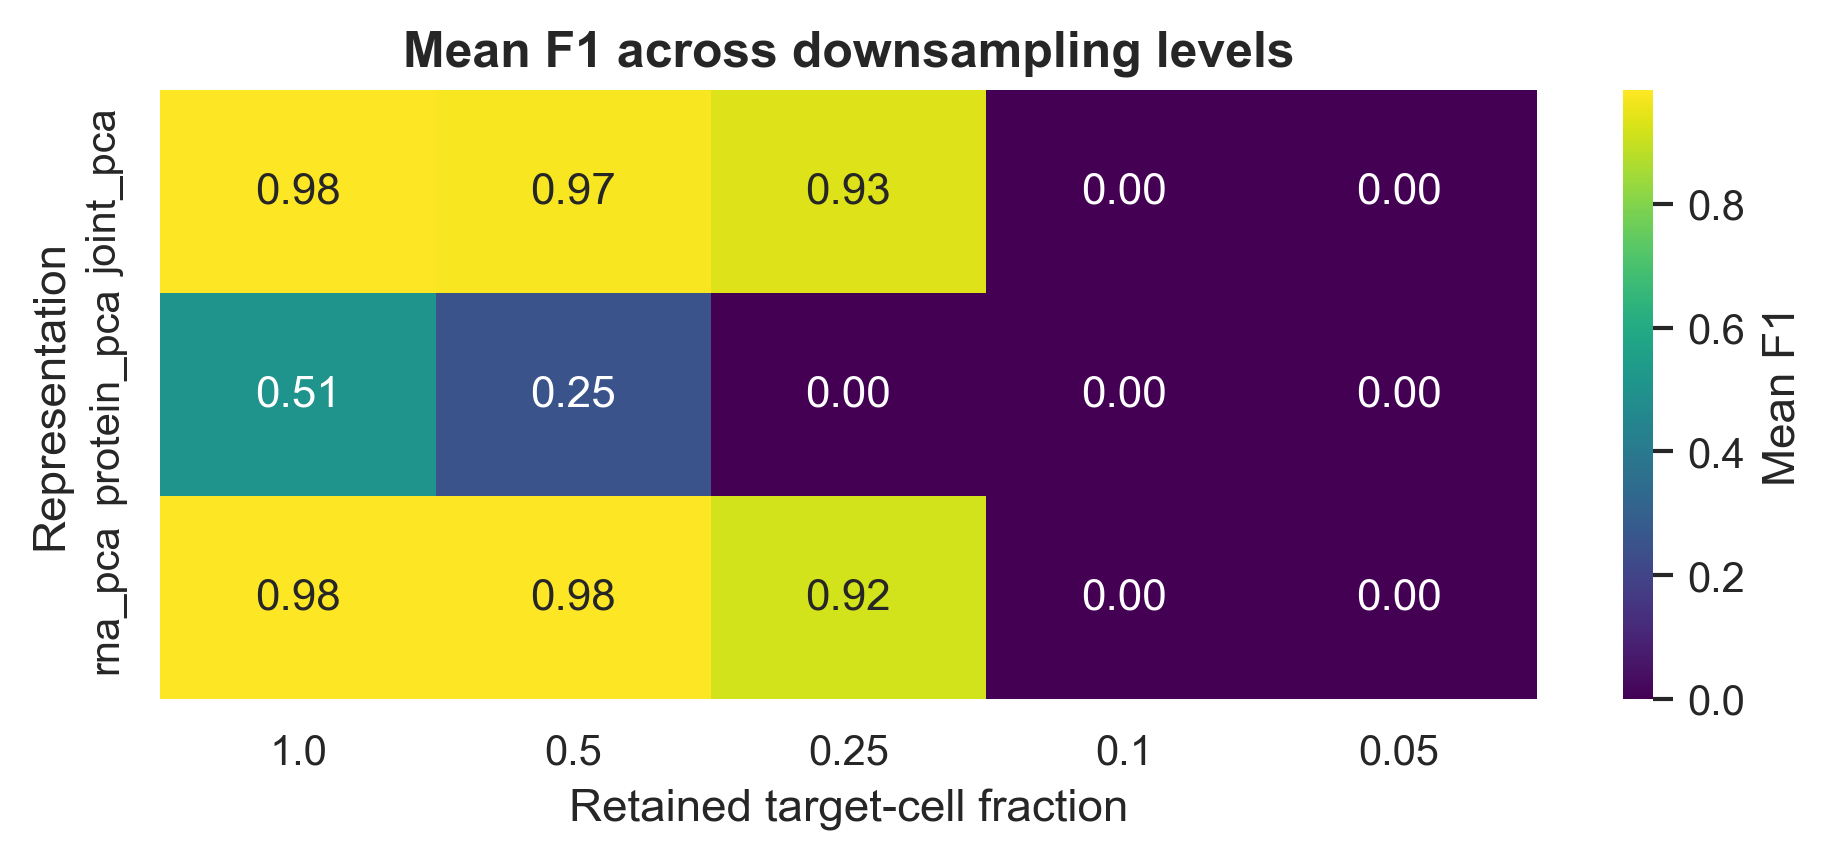

pbmc5k_14__rare_cell_recall_heatmap.png


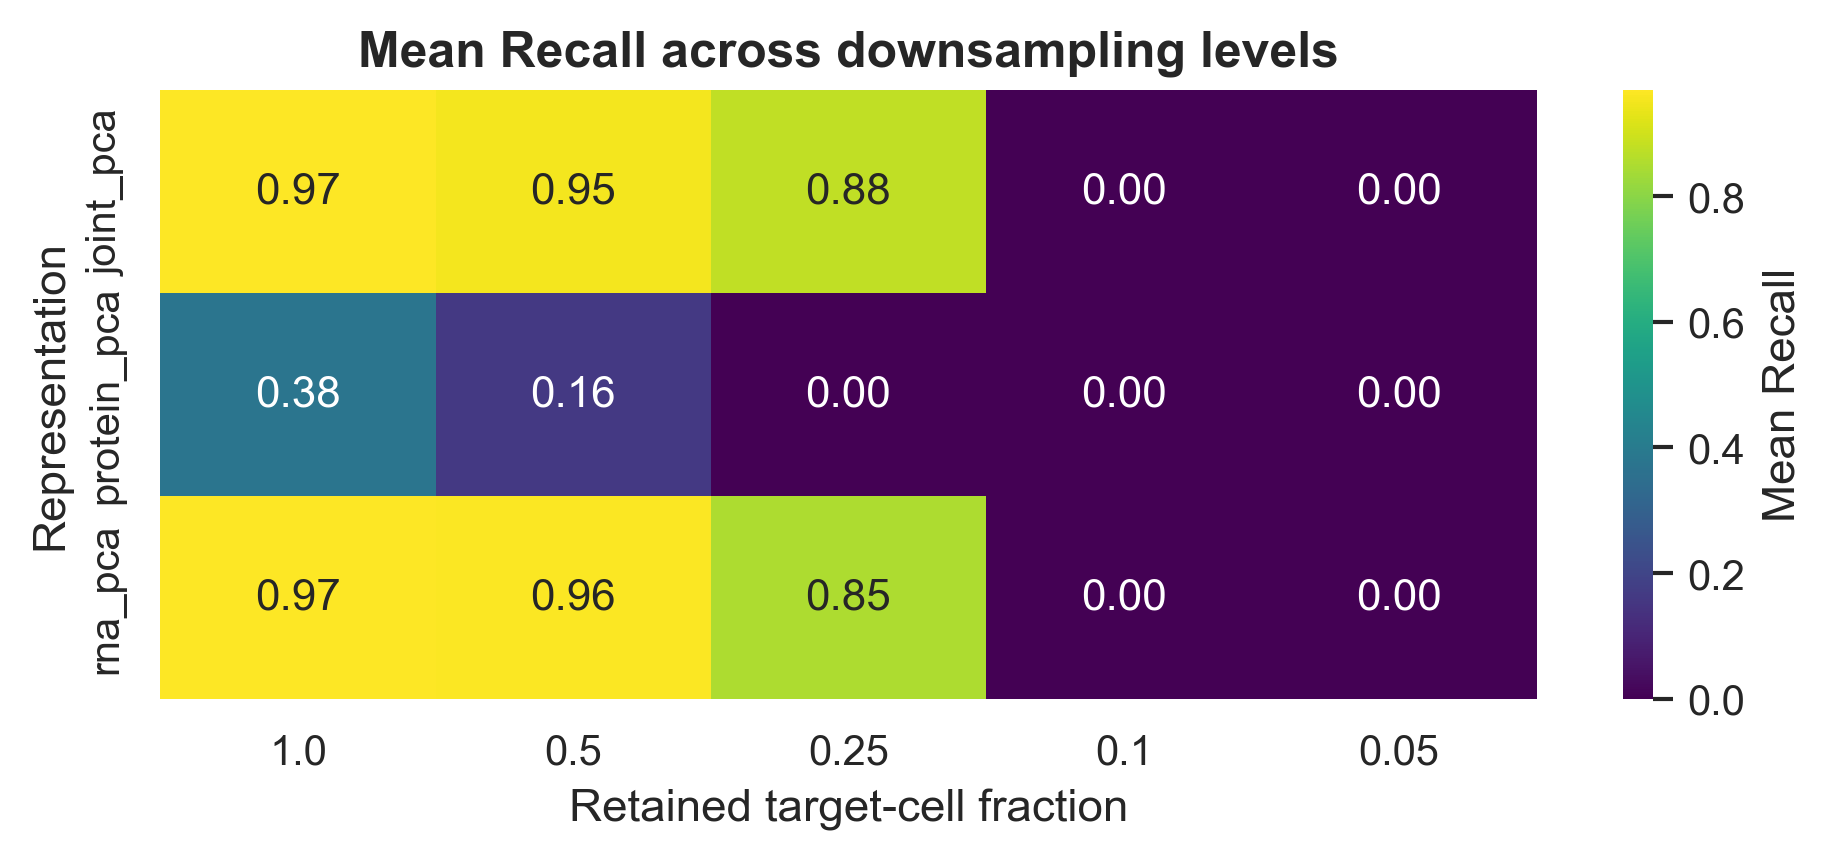

pbmc5k_14__neighborhood_purity_heatmap.png


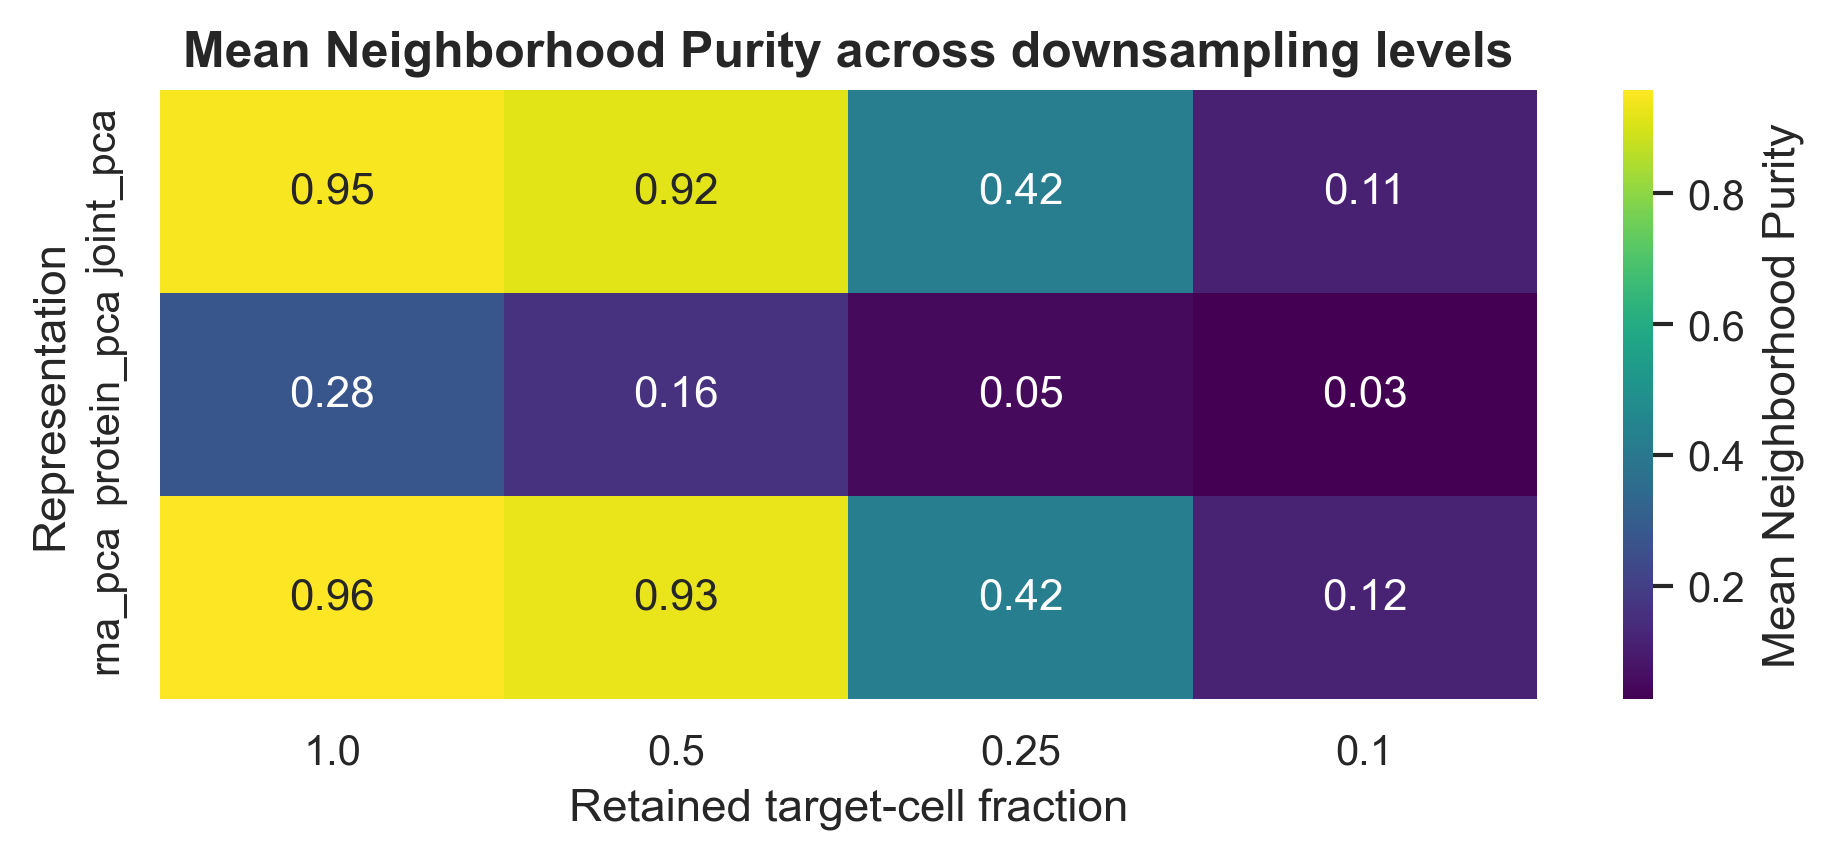

pbmc5k_14__target_silhouette_heatmap.png


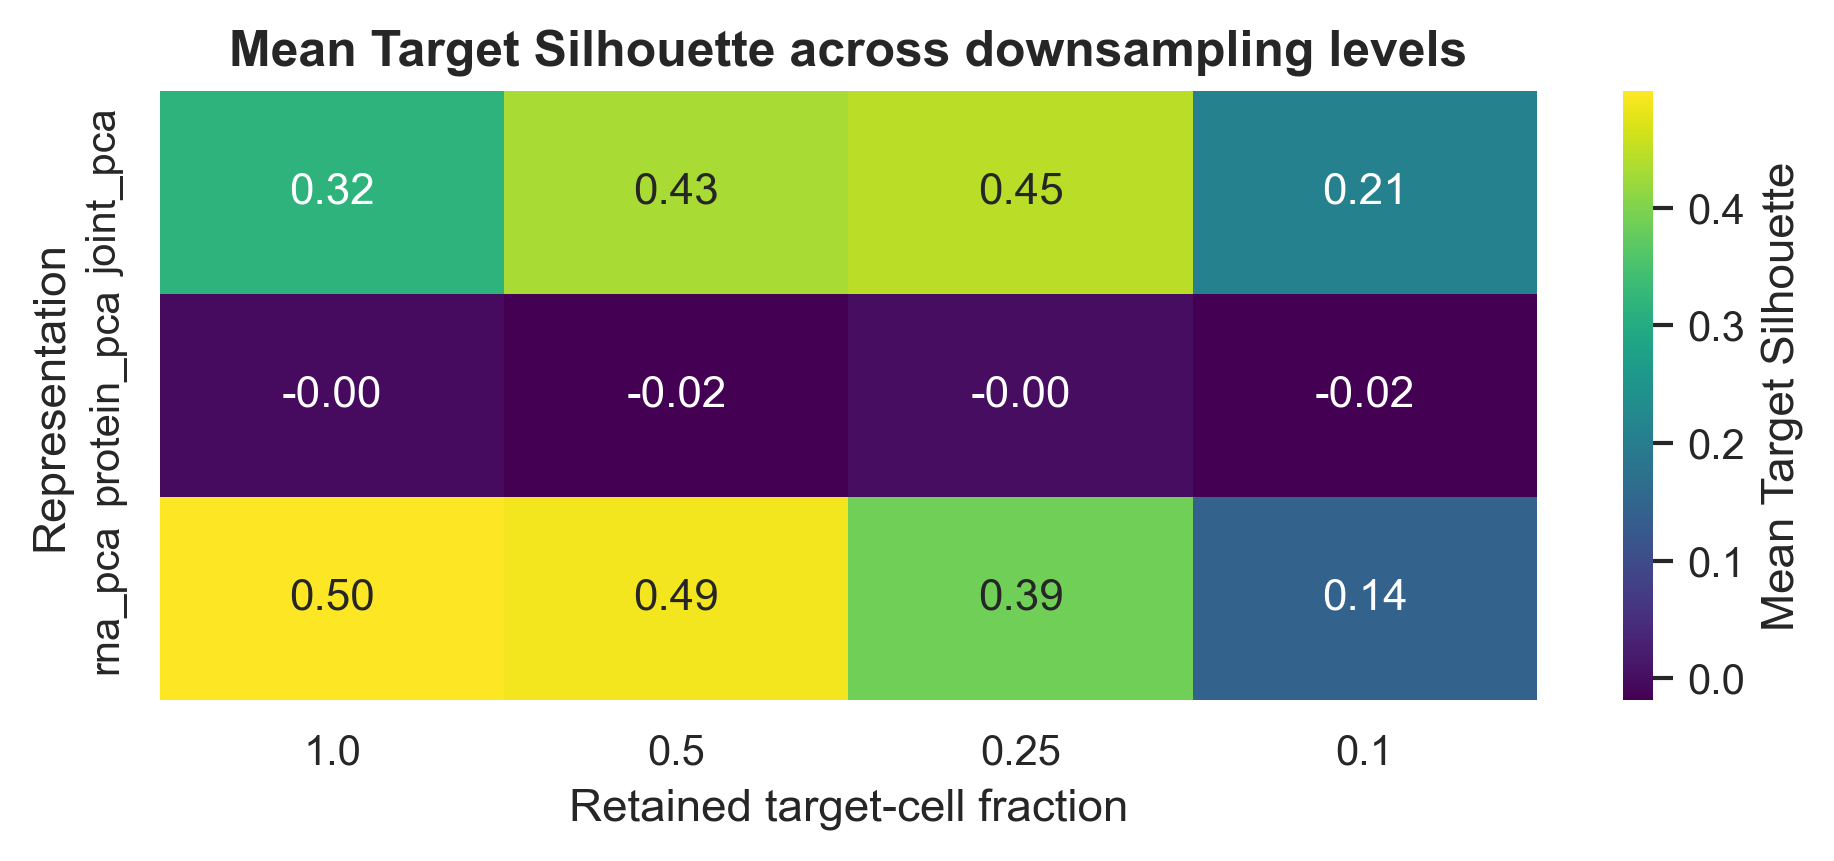

In [5]:
for path in plot_paths:
    if str(path).endswith(".png"):
        print(path.name)
        display(Image(filename=str(path)))


## Metric summary table

The summary shows mean metric values across seeds, grouped by representation and retained fraction.


In [6]:
if not summary.empty:
    display(summary)
else:
    from rarecell.benchmark import make_metric_summary

    summary = make_metric_summary(results)
    display(summary)


,representation,retain_fraction,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,neighborhood_purity_mean,neighborhood_purity_std,target_silhouette_mean,target_silhouette_std,n_target_mean,n_target_std
0,joint_pca,0.05,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,1.0,0.0
1,joint_pca,0.10,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.111111,0.022222,0.206280,0.089841,3.0,0.0
2,joint_pca,0.25,1.0,0.000000,0.87500,0.088388,0.931429,0.050575,0.418333,0.028504,0.446047,0.043344,8.0,0.0
3,joint_pca,0.50,1.0,0.000000,0.95000,0.027951,0.974194,0.014426,0.915000,0.030704,0.431311,0.004844,16.0,0.0
4,joint_pca,1.00,1.0,0.000000,0.96875,0.000000,0.984127,0.000000,0.950000,0.000000,0.317227,0.000000,32.0,0.0
5,protein_pca,0.05,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,1.0,0.0
6,protein_pca,0.10,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.026667,0.028974,-0.018278,0.022763,3.0,0.0
7,protein_pca,0.25,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.050000,0.016667,-0.000758,0.018346,8.0,0.0
8,protein_pca,0.50,0.8,0.447214,0.16250,0.168866,0.252871,0.231159,0.159167,0.067340,-0.017664,0.008977,16.0,0.0
9,protein_pca,1.00,0.8,0.000000,0.37500,0.000000,0.510638,0.000000,0.277083,0.000000,-0.003456,0.000000,32.0,0.0


## Auto-interpretation

This short summary identifies the best representation at the lowest retained fraction.


In [7]:
lowest_fraction = float(results["retain_fraction"].min())
metric_cols = [c for c in ["f1", "recall", "neighborhood_purity"] if c in results.columns]
mean_by_rep = (
    results[results["retain_fraction"] == lowest_fraction]
    .groupby("representation")[metric_cols]
    .mean(numeric_only=True)
    .reset_index()
)
if not mean_by_rep.empty and "f1" in mean_by_rep.columns:
    best = mean_by_rep.sort_values("f1", ascending=False).iloc[0]
    print(f"At lowest fraction ({lowest_fraction:.0%} retained target cells):")
    print(f"  Best F1:  {best['representation']} ({best['f1']:.3f})")
display(mean_by_rep.round(3))


At lowest fraction (5% retained target cells):
  Best F1:  joint_pca (0.000)


,representation,f1,recall,neighborhood_purity
0,joint_pca,0.0,0.0,NaN
1,protein_pca,0.0,0.0,NaN
2,rna_pca,0.0,0.0,NaN


## Figure index

The figure index CSV records all generated figure paths and is written alongside the figures.


In [8]:
figure_index_path = TABLES_DIR / f"{output_prefix}__figure_index.csv"
if figure_index_path.exists():
    display(pd.read_csv(figure_index_path))


,figure_name,description,png_path,pdf_path,svg_path,created_by
0,rare_cell_f1_curve,Rare-cell F1 score vs. retained fraction,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots
1,rare_cell_recall_curve,Rare-cell recall vs. retained fraction,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots
2,rare_cell_precision_curve,Rare-cell precision vs. retained fraction,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots
3,neighborhood_purity_curve,Neighborhood purity vs. retained fraction,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots
4,target_silhouette_curve,Target silhouette score vs. retained fraction,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots
5,target_cell_counts,Target-cell counts after downsampling by fraction,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots
6,rare_cell_f1_heatmap,Mean rare-cell F1 score by representation and ...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots
7,rare_cell_recall_heatmap,Mean rare-cell recall by representation and fr...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots
8,neighborhood_purity_heatmap,Mean neighborhood purity by representation and...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots
9,target_silhouette_heatmap,Mean target silhouette by representation and f...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,/Users/zeyuyao/Documents/GitHub/rarecell-cites...,NaN,save_all_standard_plots


## Summary

In [9]:
# Summary of generated outputs and deviations from run_downsampling_benchmark.py
print("Generated outputs:")
for p in sorted(set(plot_paths)):
    status = "OK" if p.exists() else "MISSING"
    try:
        rel = p.relative_to(PROJECT_ROOT)
    except ValueError:
        rel = p
    print(f"  [{status}] {rel}")

figure_index_path = TABLES_DIR / f"{output_prefix}__figure_index.csv"
if figure_index_path.exists():
    try:
        rel = figure_index_path.relative_to(PROJECT_ROOT)
    except ValueError:
        rel = figure_index_path
    print(f"  [OK] {rel}")

print()
print("Deviations from run_downsampling_benchmark.py:")
print("  - This notebook only generates figures from pre-saved benchmark results.")
print("  - The benchmark itself is run by rare_cell_downsampling_benchmark.ipynb.")


Generated outputs:
  [OK] results/figures/pbmc5k_14__neighborhood_purity_curve.pdf
  [OK] results/figures/pbmc5k_14__neighborhood_purity_curve.png
  [OK] results/figures/pbmc5k_14__neighborhood_purity_heatmap.pdf
  [OK] results/figures/pbmc5k_14__neighborhood_purity_heatmap.png
  [OK] results/figures/pbmc5k_14__rare_cell_f1_curve.pdf
  [OK] results/figures/pbmc5k_14__rare_cell_f1_curve.png
  [OK] results/figures/pbmc5k_14__rare_cell_f1_heatmap.pdf
  [OK] results/figures/pbmc5k_14__rare_cell_f1_heatmap.png
  [OK] results/figures/pbmc5k_14__rare_cell_precision_curve.pdf
  [OK] results/figures/pbmc5k_14__rare_cell_precision_curve.png
  [OK] results/figures/pbmc5k_14__rare_cell_recall_curve.pdf
  [OK] results/figures/pbmc5k_14__rare_cell_recall_curve.png
  [OK] results/figures/pbmc5k_14__rare_cell_recall_heatmap.pdf
  [OK] results/figures/pbmc5k_14__rare_cell_recall_heatmap.png
  [OK] results/figures/pbmc5k_14__target_cell_counts.pdf
  [OK] results/figures/pbmc5k_14__target_cell_counts.png